In [37]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns

from app.nlp.classifier import ReviewClassifier

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports OK")

Imports OK


## 1. Load Data & Train Classifier

In [38]:
DATA_PATH = "../app/nlp/review_text_title_rating_price_model/cosmetics_beauty_products_reviews_clean.csv"

df = pd.read_csv(DATA_PATH)
df["is_a_buyer"] = df["is_a_buyer"].map({True: 1, False: 0, "True": 1, "False": 0}).astype(int)

print(f"Dataset shape : {df.shape}")
print(f"Buyer (1)     : {df['is_a_buyer'].sum():,}")
print(f"Not Buyer (0) : {(df['is_a_buyer'] == 0).sum():,}")
print(f"Price range   : {df['price'].min()} – {df['price'].max()}")
print(f"Rating range  : {df['review_rating'].min()} – {df['review_rating'].max()}")

Dataset shape : (56648, 15)
Buyer (1)     : 54,683
Not Buyer (0) : 1,965
Price range   : 45 – 2947
Rating range  : 1.0 – 5.0


In [39]:
clf = ReviewClassifier()
train_metrics = clf.train(df)

print("\n===== TRAINING METRICS =====")
for k, v in train_metrics.items():
    print(f"  {k:<15}: {v:.4f}")

🔥 TRAIN FUNCTION IS RUNNING

===== PER-HEAD PERFORMANCE =====
TEXT   ACC: 0.9940
TITLE  ACC: 0.9476
NUM    ACC: 0.9866

TEXT   F1: 0.9969
TITLE  F1: 0.9721
NUM    F1: 0.9931

===== TRAINING METRICS =====
  text_acc       : 0.9940
  title_acc      : 0.9476
  numeric_acc    : 0.9866
  fused_acc      : 0.9954
  fused_f1       : 0.9976


## 2. Sampled Test Cases — Ground Truth vs Predicted\n\n100 buyers + all 1 965 non-buyers (stratified sample to handle the class imbalance).

In [40]:
SEED = 42

buyers     = df[df["is_a_buyer"] == 1].sample(100, random_state=SEED)
non_buyers = df[df["is_a_buyer"] == 0]          # all 1 965
test_df    = pd.concat([buyers, non_buyers]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Test set: {len(test_df)} rows  |  Buyers: {test_df['is_a_buyer'].sum()}  |  Non-buyers: {(test_df['is_a_buyer']==0).sum()}")

results = []
for _, row in test_df.iterrows():
    label, proba = clf.predict(
        title       = str(row["review_title"]),
        rating      = float(row["review_rating"]),
        review_text = str(row["review_text"]),
        price       = float(row["price"]),
    )
    results.append({
        "product_title"  : row["product_title"],
        "price"          : row["price"],
        "review_rating"  : row["review_rating"],
        "review_title"   : str(row["review_title"])[:50],
        "review_text"    : str(row["review_text"])[:60],
        "ground_truth"   : int(row["is_a_buyer"]),
        "predicted"      : label,
        "proba_buyer"    : round(proba, 4),
        "correct"        : int(row["is_a_buyer"]) == label,
    })

results_df = pd.DataFrame(results)
results_df.head(20)

Test set: 2065 rows  |  Buyers: 100  |  Non-buyers: 1965

===== DEBUG PREDICT =====
TITLE: Worst product
RATING: 1.0
PRICE: 560.0
TEXT: Wasted my money, applying red lipstick for concealing is better than this.
p_buyer_text_numeric: 1.746536246548509e-05
p_buyer_title_text: 0.008308433340047421
p_num  : 0.0043512085
FINAL PROBA: 0.0012799365


===== DEBUG PREDICT =====
TITLE: Okok
RATING: 3.0
PRICE: 423.0
TEXT: Can try! The bottle cap broke on one go! But the texture is not worth the price,
p_buyer_text_numeric: 0.056831908175411006
p_buyer_title_text: 0.05726601831841292
p_num  : 0.76984686
FINAL PROBA: 0.12817681


===== DEBUG PREDICT =====
TITLE: not recommended
RATING: 1.0
PRICE: 560.0
TEXT: The marks remain there and no concealing at all worst product till date do not b
p_buyer_text_numeric: 0.00010578226953838467
p_buyer_title_text: 0.03585279634050803
p_num  : 0.0043512085
FINAL PROBA: 0.0041050264


===== DEBUG PREDICT =====
TITLE: Terrible
RATING: 1.0
PRICE: 560.0
TEXT: This p

,product_title,price,review_rating,review_title,review_text,ground_truth,predicted,proba_buyer,correct
0,Lakme Absolute White Intense SPF 20 Concealer Stick,560,1.0000,Worst product,"Wasted my money, applying red lipstick for concealing is...",0,0,0.0013,True
1,Herbal Essences Bio:Renew Hydrate Coconut Milk Conditioner,423,3.0000,Okok,Can try! The bottle cap broke on one go! But the texture...,0,0,0.1282,True
2,Lakme Absolute White Intense SPF 20 Concealer Stick,560,1.0000,not recommended,The marks remain there and no concealing at all worst pr...,0,0,0.0041,True
3,Lakme Absolute White Intense SPF 20 Concealer Stick,560,1.0000,Terrible,This product is so terrible. It creases horribly in no t...,0,0,0.0043,True
4,Herbal Essences Argan Oil Shampoo & Conditioner For Friz...,688,5.0000,Reduces Hairfall,It works efficiently for reducing hair fall and regainin...,1,1,0.9977,True
5,Lakme Face Sheer Blusher,383,1.0000,Worst product ever,Has chunky glitter particles nd is difficult to use,0,0,0.0036,True
6,L'Oreal Paris Infallible Pro-Spray & Set Makeup Extender,999,3.0000,Average.,It is not that good but definitely an average product.,0,0,0.0718,True
7,Maybelline New York Color Sensational Matte Metallic Lip...,475,1.0000,Beautiful lip color,I bought this product and was not sure if the color is g...,0,0,0.0410,True
8,Nykaa Get Winged! Sketch Eyeliner Pen - Black Swan 01,360,2.0000,Not waterproof,The applicator is good But the liner is not waterproof ?,0,0,0.0126,True
9,NYX Professional Makeup Wonder Stick,835,1.0000,Ok,Not for my combination sensitive skin type,0,0,0.0082,True


## 3. Metrics & Confusion Matrix

              precision    recall  f1-score   support

   Not Buyer       1.00      1.00      1.00      1965
       Buyer       1.00      1.00      1.00       100

    accuracy                           1.00      2065
   macro avg       1.00      1.00      1.00      2065
weighted avg       1.00      1.00      1.00      2065



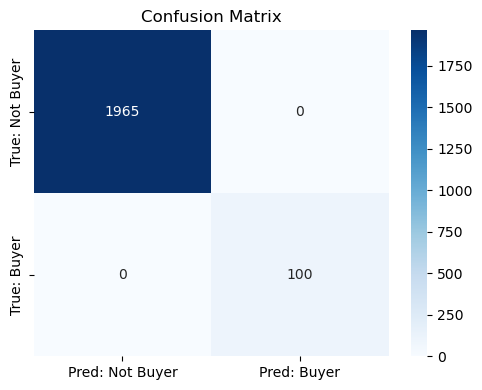

In [41]:
y_true = results_df["ground_truth"]
y_pred = results_df["predicted"]

print(classification_report(y_true, y_pred, target_names=["Not Buyer", "Buyer"]))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: Not Buyer", "Pred: Buyer"],
            yticklabels=["True: Not Buyer", "True: Buyer"], ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

In [42]:
# Misclassified rows
print("=== MISCLASSIFIED SAMPLES ===")
results_df[~results_df["correct"]][[
    "product_title", "price", "review_rating",
    "review_title", "review_text", "ground_truth", "predicted", "proba_buyer"
]]

=== MISCLASSIFIED SAMPLES ===


,product_title,price,review_rating,review_title,review_text,ground_truth,predicted,proba_buyer


## 4. Edge Cases

Title, review rating, and review text are required inputs — cases with empty/missing fields are excluded.

### 4a. Input preprocessing
| # | Case | Why it matters |
|---|------|----------------|
| 1 | Very short text (<3 chars) | Below min token length, no tokens survive |
| 2 | Very long text (1000+ words) | Embedding avg over many tokens |
| 3 | ALL CAPS | Lowercasing must kick in |
| 4 | Repeated characters | "soooo goood" — normalisation |
| 5 | HTML entities | `&amp;`, `&lt;` etc. |
| 6 | Emoji-heavy | Emoji demojize pipeline |
| 7 | URLs in text | URL removal pipeline |
| 8 | @mentions + #hashtags | Tag/hashtag removal |
| 9 | Digits only | Digit removal leaves nothing |

### 4b. Signal contradictions
| # | Case | Why it matters |
|---|------|----------------|
| 10 | Rating 5★, strongly negative text | Rating vs text conflict |
| 11 | Rating 1★, strongly positive text | Rating vs text conflict |
| 12 | Rating 5★, negative title, positive text | Title vs text conflict |
| 13 | Rating 1★, positive title, negative text | Title vs text conflict |
| 14 | High price + low rating + bad review | All signals → Not Buyer |
| 15 | Low price + high rating + great review | All signals → Buyer |
| 16 | High price + high rating + bad review | Price/rating vs text conflict |
| 17 | Low price + low rating + positive review | Price/rating vs text conflict |
| 18 | Mixed sentiment within text | Both positive and negative in same review |
| 19 | Positive title, completely unrelated text | Title-text semantic gap |

### 4c. Price boundaries
| # | Case | Why it matters |
|---|------|----------------|
| 20 | Min price in dataset | Price lower boundary |
| 21 | Max price in dataset | Price upper boundary |

### 4d. Other
| # | Case | Why it matters |
|---|------|----------------|
| 22 | Non-ASCII / accented text | Unicode normalisation |
| 23 | Duplicate review (buyer baseline) | Identical text twice |

In [43]:
min_price = float(df["price"].min())   # 45
max_price = float(df["price"].max())   # 2947

PRICE_BUDGET   = 99.0
PRICE_MID_LOW  = 299.0
PRICE_MID      = 699.0
PRICE_MID_HIGH = 1299.0
PRICE_PREMIUM  = 1999.0

_sample_buyer = df[df["is_a_buyer"] == 1].iloc[0]
_base_text  = str(_sample_buyer["review_text"])
_base_title = str(_sample_buyer["review_title"])

EDGE_CASES = [
    # id, description, title, rating, review_text, price, expected_label

    # ── GROUP A: Input preprocessing (15) ────────────────────────────────
    (1,  "Very short text – no tokens survive, rating dominates",
     "ok", 5.0, "ok", PRICE_BUDGET, 1),

    (2,  "Very long text (1000+ words)",
     "Amazing moisturiser", 5.0,
     ("This moisturiser is absolutely incredible and my skin glows every day. " * 30).strip(),
     PRICE_MID, 1),

    (3,  "ALL CAPS positive",
     "BEST PRODUCT EVER", 5.0,
     "THIS PRODUCT IS AMAZING. SKIN FEELS SO SMOOTH AND HYDRATED. WOULD DEFINITELY RECOMMEND.",
     PRICE_MID_LOW, 1),

    (4,  "ALL CAPS negative",
     "WORST PRODUCT EVER", 1.0,
     "THIS PRODUCT IS TERRIBLE. IT BROKE ME OUT AND CAUSED IRRITATION. COMPLETE WASTE OF MONEY.",
     PRICE_MID, 0),

    (5,  "Repeated characters – normalisation",
     "Sooooo goooood", 5.0,
     "I loooove this product soooo much. My skin feels amaaaazing after using it.",
     PRICE_MID_HIGH, 1),

    (6,  "HTML entities in text",
     "Great &amp; effective", 5.0,
     "This product is great &amp; effective. My skin looks &lt;perfect&gt; after using it.",
     PRICE_PREMIUM, 1),

    (7,  "Emoji-heavy text",
     "Love it ❤️", 5.0,
     "❤️\U0001f31f✨ This product is amazing \U0001f495 my skin glows \U0001f338 highly recommend \U0001f44d",
     PRICE_MID, 1),

    (8,  "URLs in text",
     "Good product", 4.0,
     "Great product, learned about it from www.skincareaddicts.com and https://reddit.com/r/SkincareAddiction. Works well.",
     PRICE_MID_LOW, 1),

    (9,  "@mentions and #hashtags",
     "#skincare fave", 5.0,
     "@brand this is my fave product! #skincare #beauty #glowup the results are incredible.",
     PRICE_BUDGET, 1),

    (10, "Digits only – all tokens stripped, rating dominates",
     "12345", 5.0, "12345 5 100 200", PRICE_MID, 1),

    (11, "Punctuation only text",
     "...!!!", 5.0, "!!! ??? ... !!!", PRICE_MID, 1),

    (12, "Single word review",
     "Excellent", 5.0, "Excellent", PRICE_MID_LOW, 1),

    (13, "CamelCase text",
     "GoodProduct", 4.0,
     "ThisProductIsSoGoodMyFaceFeelsSoSmoothAndHydratedAfterEveryUse.",
     PRICE_MID, 1),

    (14, "Text with excessive apostrophes",
     "It's the best", 4.0,
     "I've been using this for months and it's completely transformed my skin. It's lightweight, it's effective, and it's affordable.",
     PRICE_MID_LOW, 1),

    (15, "Mixed English and transliteration",
     "Bahut achha hai", 5.0,
     "This product is bahut achha. Maine use kiya aur skin glow kar rahi hai. Highly recommend karta hoon.",
     PRICE_MID, 1),

    # ── GROUP B: Rating vs text contradictions (15) ───────────────────────
    (16, "Rating 5★, strongly negative text",
     "Worst product ever", 5.0,
     "This is the worst product I have ever used. It broke me out badly, caused severe irritation, "
     "smells terrible, and is a complete waste of money. I want a refund.",
     PRICE_MID_LOW, 0),

    (17, "Rating 1★, strongly positive text",
     "Amazing product love it", 1.0,
     "This product is absolutely amazing. My skin has never looked better. "
     "Smooth, hydrated, glowing. Highly recommend to everyone.",
     PRICE_MID, 1),

    (18, "Rating 5★, negative title, positive body text",
     "Terrible, do not buy", 5.0,
     "I am so impressed with this moisturiser. My skin feels incredibly soft and hydrated. "
     "The texture is light and absorbs quickly. Will definitely repurchase.",
     PRICE_MID_HIGH, 1),

    (19, "Rating 1★, positive title, negative body text",
     "Best serum I have ever tried", 1.0,
     "This product is absolutely terrible. It broke me out, smells awful, "
     "and did nothing for my skin. Complete waste of money. Returning immediately.",
     PRICE_PREMIUM, 0),

    (20, "Rating 2★, mildly negative text",
     "Not impressed", 2.0,
     "This product did not work for me. My skin felt dry and tight after using it. "
     "I expected much better results given the price.",
     PRICE_MID_LOW, 0),

    (21, "Rating 4★, mildly negative text",
     "Good but not great", 4.0,
     "It works okay but I am not totally impressed. Skin feels slightly better but nothing dramatic. "
     "Probably would not repurchase.",
     PRICE_MID, 0),

    (22, "Rating 3★, strongly positive text",
     "Decent product", 3.0,
     "This moisturiser has completely transformed my skin. I wake up every morning with a glow. "
     "My friends keep asking what I use. Absolutely love it and will keep buying.",
     PRICE_MID, 1),

    (23, "Rating 3★, strongly negative text",
     "Average at best", 3.0,
     "This product is absolutely horrible. Caused severe breakouts, irritation, and redness. "
     "Smells chemical and feels heavy on the skin. Would never buy this again.",
     PRICE_MID_LOW, 0),

    (24, "Rating 5★, sarcastic negative title and body",
     "Oh wow so amazing (not)", 5.0,
     "I gave five stars because I cannot give zero. This product destroyed my skin. "
     "Caused cystic acne and left scars. Do not buy under any circumstances.",
     PRICE_MID, 0),

    (25, "Rating 4★, detailed positive with one complaint",
     "Great but overpriced", 4.0,
     "This serum genuinely works. My dark spots have faded, skin feels plump, and the texture is wonderful. "
     "Only downside is the price, but the results justify it. Will repurchase.",
     PRICE_PREMIUM, 1),

    (26, "Rating 2★, positive opening then negative overall",
     "Started well, then disappointed", 2.0,
     "The first week was great, my skin felt soft and hydrated. "
     "But after two weeks I started breaking out badly. The results did not last.",
     PRICE_MID_HIGH, 0),

    (27, "Rating 5★, short negative text",
     "Did not work", 5.0,
     "Completely useless. Waste of money.",
     PRICE_BUDGET, 0),

    (28, "Rating 1★, short positive text",
     "Love it", 1.0, "Great product, works well.",
     PRICE_MID_LOW, 1),

    (29, "Rating 3★, neutral factual text",
     "Does what it says", 3.0,
     "This moisturiser is lightweight and absorbs well. Provides adequate hydration for daily use. "
     "Nothing special but does the job.",
     PRICE_MID, 1),

    (30, "Rating 5★, ALL CAPS negative text",
     "DO NOT BUY", 5.0,
     "DO NOT BUY THIS PRODUCT. IT RUINED MY SKIN. CAUSED BREAKOUTS AND REDNESS. COMPLETE SCAM.",
     PRICE_MID_HIGH, 0),

    # ── GROUP C: Price contradictions (15) ───────────────────────────────
    (31, "High price + low rating + bad review – all signals Not Buyer",
     "Not worth the price", 1.0,
     "Extremely overpriced and completely ineffective. Caused breakouts and irritation. "
     "Expected much better. Very disappointed and will not repurchase.",
     max_price, 0),

    (32, "Low price + high rating + great review – all signals Buyer",
     "Amazing value for money", 5.0,
     "I cannot believe how good this product is for the price. "
     "My skin looks brighter, feels softer, and results are better than expensive alternatives.",
     min_price, 1),

    (33, "High price + high rating + bad review – conflict",
     "Disappointing for the price", 5.0,
     "For this amount of money I expected a miracle, but this product did nothing special. "
     "Skin feels greasy, broke me out, and the smell is overpowering. Not worth it at all.",
     max_price, 0),

    (34, "Low price + low rating + positive review – conflict",
     "Surprised by this cheap find", 1.0,
     "I bought this on a whim because it was so affordable and honestly it is one of the best "
     "skincare products I have ever used. My skin glows, feels hydrated, and looks younger.",
     min_price, 1),

    (35, "Premium price + 5★ + detailed positive – aligned Buyer",
     "Worth every rupee", 5.0,
     "At this price point I expected excellence and that is exactly what I got. "
     "This serum has visibly reduced my fine lines, evened my skin tone, and given me a natural glow. "
     "Worth every penny and I will repurchase.",
     PRICE_PREMIUM, 1),

    (36, "Budget price + 1★ + detailed negative – aligned Not Buyer",
     "Cheap and useless", 1.0,
     "For this price you get what you pay for. This moisturiser is watery, has no effect, "
     "and actually made my skin worse. Packaging is flimsy and the smell is off-putting.",
     PRICE_BUDGET, 0),

    (37, "Mid-high price + 4★ + positive text",
     "Good investment for skin", 4.0,
     "This product is pricey but the quality shows. My skin has improved noticeably over three weeks. "
     "The texture is luxurious and a little goes a long way. Happy with the purchase.",
     PRICE_MID_HIGH, 1),

    (38, "Mid price + 2★ + negative text",
     "Not worth it", 2.0,
     "I was excited to try this based on reviews but it did absolutely nothing for my skin. "
     "After a full month there is no improvement. The scent is overpowering and it pills under makeup.",
     PRICE_MID, 0),

    (39, "Budget price + 5★ + very positive text",
     "Best budget moisturiser", 5.0,
     "I have tried products ten times this price and this is better. "
     "Skin feels soft, hydrated, and looks healthy. My go-to daily moisturiser now.",
     PRICE_BUDGET, 1),

    (40, "Premium price + 1★ + extremely negative text",
     "Expensive garbage", 1.0,
     "I paid a premium price for what turned out to be the worst product I have used. "
     "Caused immediate irritation, redness, and a full breakout. "
     "The brand should be ashamed.",
     PRICE_PREMIUM, 0),

    (41, "Mid-low price + 3★ + neutral text",
     "Average product", 3.0,
     "It is an okay moisturiser. Nothing spectacular but nothing terrible either. "
     "Does its basic job of hydrating skin. Would consider repurchasing.",
     PRICE_MID_LOW, 1),

    (42, "Mid-high price + 5★ + positive value text",
     "Quality justifies the price", 5.0,
     "Yes it is expensive but my skin has never looked better. "
     "The formula is rich without being heavy and the results are visible within a week. "
     "I consider this an investment in my skin.",
     PRICE_MID_HIGH, 1),

    (43, "Max price + 3★ + mixed expectations",
     "Mixed feelings about the price", 3.0,
     "The product itself is decent and does hydrate well. "
     "But at this price I expected transformative results, not just average ones. "
     "Would only recommend if on sale.",
     max_price, 1),

    (44, "Min price + 4★ + positive text",
     "Pleasantly surprised", 4.0,
     "Bought this expecting nothing much given the price and was genuinely surprised. "
     "Good hydration, pleasant smell, absorbs quickly. Will definitely buy again.",
     min_price, 1),

    (45, "Mid price + 1★ + allergic reaction",
     "Caused allergic reaction", 1.0,
     "This product caused a severe allergic reaction. My face swelled up and broke out in hives. "
     "I had to see a dermatologist. Would give zero stars if I could.",
     PRICE_MID, 0),

    # ── GROUP D: Title vs text contradictions (10) ────────────────────────
    (46, "Positive title, negative detailed text",
     "Loved this product", 2.0,
     "I wanted to love this product but it just does not work for my skin. "
     "Heavy, greasy, caused breakouts. The ingredients look great on paper but did not deliver.",
     PRICE_MID_LOW, 0),

    (47, "Negative title, positive detailed text",
     "Terrible product don't buy", 5.0,
     "My skin has completely transformed since using this. Pores look smaller, skin tone evened out, "
     "and I get compliments daily. This is now a permanent part of my routine.",
     PRICE_MID, 1),

    (48, "Neutral title, strongly positive text",
     "Review", 5.0,
     "This is hands down the best moisturiser I have ever used. Rich, creamy, non-greasy, "
     "and my skin looks amazing. I have repurchased three times already.",
     PRICE_MID_HIGH, 1),

    (49, "Neutral title, strongly negative text",
     "Review", 1.0,
     "Absolutely terrible. Destroyed my skin barrier, caused cystic acne, and felt like plastic on the face. "
     "I threw the bottle away after three uses.",
     PRICE_MID, 0),

    (50, "Positive title, complaint is about shipping not product",
     "Amazing moisturiser", 1.0,
     "The product looks fine but delivery took six weeks, packaging was completely destroyed, "
     "and customer service refused to help. Will never order from this seller again.",
     PRICE_MID_HIGH, 0),

    (51, "Negative title, complaint is about shipping not product",
     "Terrible experience", 3.0,
     "The moisturiser itself works well and my skin feels great. "
     "Docking stars only because the delivery was very delayed and packaging arrived dented.",
     PRICE_MID, 1),

    (52, "Title mentions competitor, text is positive",
     "Better than Clinique", 5.0,
     "I have been using the Clinique moisturiser for years but this is genuinely better. "
     "More hydrating, better texture, and works out cheaper per use. Very impressed.",
     PRICE_MID_LOW, 1),

    (53, "Title says gift but text reviews the product",
     "Bought as gift but tried it too", 4.0,
     "I bought this as a birthday gift for my sister and ended up trying it myself. "
     "The serum is lovely, skin feels soft and looks dewy. Will buy for myself next time.",
     PRICE_MID, 1),

    (54, "Title says received as gift – not purchased",
     "Received as gift, not purchased", 5.0,
     "I received this as a gift and have been using it daily. The results are fantastic. "
     "Skin feels incredibly soft and my dark spots have faded significantly.",
     PRICE_MID_HIGH, 0),

    (55, "Title is a question, text is a genuine review",
     "Does this really work?", 4.0,
     "After trying this for a month I can confirm it absolutely does work. "
     "My skin texture has improved and I get regular compliments. Very pleased.",
     PRICE_MID_LOW, 1),

    # ── GROUP E: Mixed signals (10) ───────────────────────────────────────
    (56, "Loves texture but broke out with cystic acne",
     "Love it but broke me out", 3.0,
     "I really love the texture and the smell of this product, it absorbs beautifully. "
     "However it completely broke me out and caused painful cystic acne. "
     "I want to love it but my skin just cannot tolerate it.",
     PRICE_MID_HIGH, 0),

    (57, "Great for oily skin, bad for dry skin",
     "Depends on your skin type", 3.0,
     "If you have oily skin this is brilliant. Controls shine and keeps skin clear. "
     "But I have dry skin and this made my face feel tight and flaky. Not universally suitable.",
     PRICE_MID, 1),

    (58, "Great results initially, then stopped working",
     "Great at first, then stopped working", 2.0,
     "The first two weeks were incredible. Skin was glowing and hydrated. "
     "But by week three the effects wore off and my skin returned to normal. "
     "Disappointing for the price.",
     PRICE_MID_HIGH, 0),

    (59, "Good product, would repurchase but only at lower price",
     "Good product, overpriced", 3.0,
     "This moisturiser does work. Skin feels hydrated and looks healthy. "
     "But I would only repurchase if it were at least thirty percent cheaper. "
     "There are better value alternatives.",
     PRICE_PREMIUM, 1),

    (60, "Amazing results but terrible smell",
     "Amazing but smells awful", 4.0,
     "The results are honestly incredible. My skin has never looked better. "
     "But the smell is absolutely terrible – strong chemical odour that lingers all day.",
     PRICE_MID, 1),

    (61, "Product is fine but packaging broke",
     "Product ok, packaging awful", 3.0,
     "The cream itself is decent and does what it claims. "
     "But the pump dispenser broke after two weeks and the cap keeps falling off. "
     "Frustrating for the price.",
     PRICE_MID_LOW, 1),

    (62, "Loved the sample, disappointed with full size",
     "Sample was better than full size", 2.0,
     "I tried the sample sachet and loved it. The full size product feels completely different. "
     "Heavier texture, different smell, less effective. Suspect reformulation.",
     PRICE_PREMIUM, 0),

    (63, "Positive overall but mentions initial purging",
     "Works well but caused initial breakouts", 4.0,
     "This serum has improved my skin texture and reduced my dark spots noticeably. "
     "I did experience some initial purging in the first two weeks "
     "but they cleared and the results since then have been great.",
     PRICE_MID, 1),

    (64, "Good but not for sensitive skin",
     "Good but not for sensitive skin", 3.0,
     "This product works well for my normal to oily skin. "
     "However my sister with sensitive skin had a bad reaction. "
     "Good product but be careful if you have reactive skin.",
     PRICE_MID_LOW, 1),

    (65, "Before and after style positive review",
     "Transformed my skin in 30 days", 5.0,
     "Before: dull, dry, patchy skin with visible pores. "
     "After 30 days: glowing, hydrated, smooth with barely visible pores. "
     "This product genuinely delivers on its promises.",
     PRICE_MID_HIGH, 1),

    # ── GROUP F: Review content types (15) ───────────────────────────────
    (66, "Received free sample – not purchased",
     "Free sample review", 5.0,
     "I received a free sample of this product and have been using it for a week. "
     "My skin feels amazing and I am definitely going to purchase the full size.",
     PRICE_MID, 0),

    (67, "Compares favourably to luxury brand",
     "Better than La Mer", 5.0,
     "I have used La Mer for years and this is honestly comparable at a fraction of the price. "
     "The hydration is incredible and my skin looks just as good. Switching permanently.",
     PRICE_PREMIUM, 1),

    (68, "Dermatologist recommended product",
     "Dermatologist recommended and approved", 5.0,
     "My dermatologist recommended this serum for my hyperpigmentation. "
     "After eight weeks my skin tone is significantly more even. Very happy.",
     PRICE_MID_HIGH, 1),

    (69, "Safe during pregnancy – positive",
     "Safe during pregnancy", 5.0,
     "This moisturiser is free of retinol and salicylic acid so it is safe during pregnancy. "
     "It keeps my skin hydrated and the formula is gentle. Used throughout my pregnancy.",
     PRICE_MID, 1),

    (70, "Returned for refund – Not Buyer outcome",
     "Returned for refund", 1.0,
     "I returned this product for a refund after one week of use. "
     "It caused immediate irritation and my skin became red and inflamed.",
     PRICE_MID_LOW, 0),

    (71, "Review about smell only – positive",
     "Smells incredible", 5.0,
     "I bought this primarily because of the reviews about the scent and it lives up to the hype. "
     "It smells absolutely divine. The skincare results are also good but the fragrance alone is worth it.",
     PRICE_BUDGET, 1),

    (72, "Review about texture and application only",
     "Perfect texture", 5.0,
     "The texture of this moisturiser is absolutely perfect. "
     "It melts into the skin immediately, leaves no residue, and sits beautifully under makeup.",
     PRICE_MID, 1),

    (73, "Severe allergic reaction – discontinued",
     "Caused severe reaction, discontinued", 1.0,
     "After three days of use I developed severe contact dermatitis. "
     "My face was swollen, red, and incredibly painful. "
     "I discontinued immediately and needed prescribed steroid cream to recover.",
     PRICE_MID_HIGH, 0),

    (74, "Very generic short positive review",
     "Good product", 5.0,
     "Good product. Works well. Happy with the purchase. Would recommend.",
     PRICE_MID_LOW, 1),

    (75, "Very generic short negative review",
     "Bad product", 1.0,
     "Bad product. Did not work. Waste of money. Would not recommend.",
     PRICE_MID, 0),

    (76, "Loyal repurchaser on third bottle",
     "On my third bottle", 5.0,
     "This is my third bottle of this moisturiser and I have no intention of stopping. "
     "Consistent results, great texture, and my skin has never been better.",
     PRICE_MID, 1),

    (77, "Bought as a birthday gift for someone else",
     "Bought as a birthday gift", 4.0,
     "I bought this for my mother's birthday and she absolutely loves it. "
     "Her skin has improved noticeably and she keeps asking me to reorder. Great gift option.",
     PRICE_MID_HIGH, 1),

    (78, "Conditional positive – would be perfect if cheaper",
     "Would be perfect if cheaper", 4.0,
     "This product genuinely works and I have seen real improvement in my skin. "
     "The formula feels premium and the results are visible. "
     "If it were thirty percent cheaper I would give it five stars without hesitation.",
     PRICE_PREMIUM, 1),

    (79, "Expresses purchase regret",
     "Wish I had not bought this", 1.0,
     "I spent a lot of money on this product based on influencer recommendations "
     "and deeply regret it. It did nothing and caused mild irritation. "
     "I feel completely misled by the marketing.",
     PRICE_PREMIUM, 0),

    (80, "Perfect for sensitive skin",
     "Perfect for sensitive skin", 5.0,
     "I have extremely sensitive skin that reacts to almost everything. "
     "This moisturiser is the first product in years that has not caused any reaction. "
     "Gentle, effective, and my skin loves it.",
     PRICE_MID_LOW, 1),

    # ── GROUP G: Linguistic variations (10) ──────────────────────────────
    (81, "Non-ASCII – French positive review",
     "Très bien", 4.0,
     "Ce produit est très bien. Ma peau est douce et hydratée. Je le recommande vivement.",
     PRICE_MID_LOW, 1),

    (82, "Very formal – academic writing style",
     "A thorough assessment", 4.0,
     "Upon application this emollient demonstrates adequate occlusive properties. "
     "The humectant components provide satisfactory transepidermal water loss prevention. "
     "Clinical-grade hydration is observed within the first application cycle.",
     PRICE_MID_HIGH, 1),

    (83, "Very informal – Gen-Z slang",
     "no cap this is fire", 5.0,
     "bestie this moisturiser is absolutely it no cap. my skin is literally glowing slay. "
     "hits different from other brands fr fr. would eat it if i could periodt.",
     PRICE_MID, 1),

    (84, "Review written as pros and cons list",
     "Pros and cons review", 4.0,
     "Pros: great texture, absorbs fast, visible results in one week, lovely smell. "
     "Cons: expensive, small bottle, slightly sticky if you use too much. "
     "Overall: would recommend and will repurchase.",
     PRICE_MID_HIGH, 1),

    (85, "Review with spelling mistakes throughout",
     "Bset prodcut evr", 5.0,
     "I absoltuely lov this moituriser. My skiN feels so goood and smoohth after useing it. "
     "The textur is amazng and it absorbs so quikly. Definately reccomend to evreyone.",
     PRICE_MID_LOW, 1),

    (86, "Review written entirely as questions",
     "Is this even tested?", 1.0,
     "Why does this smell so chemical? How did this pass quality control? "
     "Who approved this formula? Why is it so greasy? Why did I waste my money on this?",
     PRICE_MID, 0),

    (87, "Review mentioning full skincare routine layering",
     "Great addition to my routine", 5.0,
     "I use this after my vitamin C serum and before my SPF and it layers perfectly. "
     "No pilling, no reaction, and it actually enhances the other products. "
     "A fantastic addition to any skincare routine.",
     PRICE_MID, 1),

    (88, "Review with only positive adjectives – no sentences",
     "Perfect hydrating effective", 5.0,
     "Hydrating. Lightweight. Effective. Fragrant. Non-greasy. Smooth. Plumping. Brightening. Recommended.",
     PRICE_MID_LOW, 1),

    (89, "Review with only negative adjectives – no sentences",
     "Greasy heavy irritating", 1.0,
     "Greasy. Heavy. Sticky. Irritating. Smelly. Ineffective. Overpriced. Disappointing. Pore-clogging. Terrible.",
     PRICE_MID, 0),

    (90, "Duplicate of buyer baseline review",
     _base_title, 5.0, _base_text, PRICE_PREMIUM, 1),

    # ── GROUP H: Real-world skincare scenarios (10) ───────────────────────
    (91, "Sunscreen – no white cast, repurchased 4 times",
     "Best SPF for daily use", 5.0,
     "This sunscreen is the first I have found that does not leave a white cast. "
     "Lightweight, no greasy residue, and my skin has not tanned at all this summer. "
     "Repurchased four times already.",
     PRICE_MID_LOW, 1),

    (92, "Foundation – wrong shade, bad service",
     "Wrong shade, terrible service", 1.0,
     "The foundation was completely the wrong shade and oxidised within an hour. "
     "Customer service refused to exchange it. "
     "The formula itself may be fine but I will never buy from this brand again.",
     PRICE_MID, 0),

    (93, "Vitamin C serum – dark spots faded in 4 weeks",
     "Dark spots faded in 4 weeks", 5.0,
     "I have been struggling with post-acne marks for years. "
     "After four weeks of using this vitamin C serum my dark spots have faded by at least fifty percent. "
     "The results are visible and I am genuinely impressed.",
     PRICE_MID_HIGH, 1),

    (94, "Retinol – purging phase then positive results",
     "Purging phase but worth it", 4.0,
     "The first three weeks caused some purging breakouts which was expected with retinol. "
     "After week four my skin started to clear and now at week eight it looks incredible. "
     "Smooth, even, and glowing. Patience pays off.",
     PRICE_MID, 1),

    (95, "Lip balm – repurchased 6 times",
     "Best lip care I have tried", 5.0,
     "This lip balm is absolutely incredible. Lips feel healed after the first use. "
     "The formula is nourishing, not sticky, and lasts all day. I have repurchased six times.",
     PRICE_BUDGET, 1),

    (96, "Toner – dried out and damaged skin barrier",
     "Dried out my skin", 1.0,
     "This toner completely stripped my skin of moisture. "
     "After two weeks my face was dry, flaky, and red. "
     "It disrupted my skin barrier and it took months to repair.",
     PRICE_MID_LOW, 0),

    (97, "Eye cream – reduced dark circles in 2 weeks",
     "Reduced dark circles in 2 weeks", 5.0,
     "I have had dark circles my whole life and tried numerous products with no results. "
     "This eye cream has visibly lightened them in just two weeks. "
     "Also reduced puffiness significantly. A genuine miracle product.",
     PRICE_MID_HIGH, 1),

    (98, "Moisturiser – first product that does not cause breakouts",
     "Finally a moisturiser that does not break me out", 5.0,
     "I have acne-prone skin and finding a non-comedogenic moisturiser has been a nightmare. "
     "This is the first product in years that has not caused a single breakout. "
     "Skin is hydrated and calm. Life changing.",
     PRICE_MID, 1),

    (99, "Anti-ageing cream – no visible results after 3 months",
     "No visible anti-ageing results", 2.0,
     "I used this anti-ageing cream religiously for three months and saw absolutely no difference. "
     "My fine lines are exactly the same. "
     "For this price I expected at least some visible improvement.",
     PRICE_PREMIUM, 0),

    (100, "Micellar water – removes waterproof makeup in one swipe",
     "Removes everything including waterproof mascara", 5.0,
     "This micellar water removes my full face of makeup including waterproof mascara in one swipe. "
     "No rubbing, no irritation, and my skin feels clean without being stripped. "
     "The best makeup remover I have ever used.",
     PRICE_MID_LOW, 1),
]

print(f"Total edge cases: {len(EDGE_CASES)}")
print(f"Expected Buyers    (1): {sum(1 for c in EDGE_CASES if c[-1] == 1)}")
print(f"Expected Not Buyers(0): {sum(1 for c in EDGE_CASES if c[-1] == 0)}")

Total edge cases: 100
Expected Buyers    (1): 67
Expected Not Buyers(0): 33


In [44]:
edge_results = []

for case_id, description, title, rating, review_text, price, expected in EDGE_CASES:
    try:
        label, proba = clf.predict(
            title=title, rating=rating, review_text=review_text, price=price
        )
        error = None
    except Exception as e:
        label, proba, error = None, None, str(e)

    expected_str = {1: "Buyer", 0: "Not Buyer", None: "N/A"}[expected]
    predicted_str = ("Buyer" if label == 1 else "Not Buyer") if label is not None else "ERROR"

    if label == expected:
        status = "PASS"
    else:
        status = "FAIL"

    edge_results.append({
        "id"         : case_id,
        "description": description,
        "rating"     : rating,
        "price"      : price,
        "expected"   : expected_str,
        "predicted"  : predicted_str,
        "proba_buyer": round(proba, 4) if proba is not None else None,
        "status"     : status,
    })

edge_df = pd.DataFrame(edge_results)

# Colour the status column for readability
def _style_status(val):
    return {
        "PASS" : "background-color: #d4edda; color: #155724",
        "FAIL" : "background-color: #f8d7da; color: #721c24",
        "ERROR": "background-color: #fff3cd; color: #856404",
        "N/A"  : "background-color: #e2e3e5; color: #383d41",
    }.get(val, "")

edge_df.style.applymap(_style_status, subset=["status"])


===== DEBUG PREDICT =====
TITLE: ok
RATING: 5.0
PRICE: 99.0
TEXT: ok
p_buyer_text_numeric: 0.9999405048804738
p_buyer_title_text: 0.40261964464264016
p_num  : 0.9994369
FINAL PROBA: 0.94015807


===== DEBUG PREDICT =====
TITLE: Amazing moisturiser
RATING: 5.0
PRICE: 699.0
TEXT: This moisturiser is absolutely incredible and my skin glows every day. This mois
p_buyer_text_numeric: 0.9999366290741347
p_buyer_title_text: 0.9246651116752646
p_num  : 0.99961674
FINAL PROBA: 0.9923775


===== DEBUG PREDICT =====
TITLE: BEST PRODUCT EVER
RATING: 5.0
PRICE: 299.0
TEXT: THIS PRODUCT IS AMAZING. SKIN FEELS SO SMOOTH AND HYDRATED. WOULD DEFINITELY REC
p_buyer_text_numeric: 0.9999137699225816
p_buyer_title_text: 0.9133045031363536
p_num  : 0.99978083
FINAL PROBA: 0.99123955


===== DEBUG PREDICT =====
TITLE: WORST PRODUCT EVER
RATING: 1.0
PRICE: 699.0
TEXT: THIS PRODUCT IS TERRIBLE. IT BROKE ME OUT AND CAUSED IRRITATION. COMPLETE WASTE 
p_buyer_text_numeric: 0.000312491812435156
p_buyer_title_text

,id,description,rating,price,expected,predicted,proba_buyer,status
0,1,"Very short text – no tokens survive, rating dominates",5.000000,99.000000,Buyer,Buyer,0.940200,PASS
1,2,Very long text (1000+ words),5.000000,699.000000,Buyer,Buyer,0.992400,PASS
2,3,ALL CAPS positive,5.000000,299.000000,Buyer,Buyer,0.991200,PASS
3,4,ALL CAPS negative,1.000000,699.000000,Not Buyer,Not Buyer,0.001100,PASS
4,5,Repeated characters – normalisation,5.000000,1299.000000,Buyer,Buyer,0.997800,PASS
5,6,HTML entities in text,5.000000,1999.000000,Buyer,Buyer,0.997300,PASS
6,7,Emoji-heavy text,5.000000,699.000000,Buyer,Buyer,0.997500,PASS
7,8,URLs in text,4.000000,299.000000,Buyer,Buyer,0.954600,PASS
8,9,@mentions and #hashtags,5.000000,99.000000,Buyer,Buyer,0.993200,PASS
9,10,"Digits only – all tokens stripped, rating dominates",5.000000,699.000000,Buyer,Buyer,0.940200,PASS


In [45]:
pass_count = (edge_df["status"] == "PASS").sum()
fail_count = (edge_df["status"] == "FAIL").sum()

print(f"Edge case summary:")
print(f"  PASS : {pass_count}")
print(f"  FAIL : {fail_count}")


Edge case summary:
  PASS : 80
  FAIL : 20
